# Logistic Regression

Model Accuracy: 100.0 %

Confusion Matrix:
 [[2 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         2
        Pass       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Enter study hours: 12
Predicted Result: Pass
Pass Probability: 99.92 %


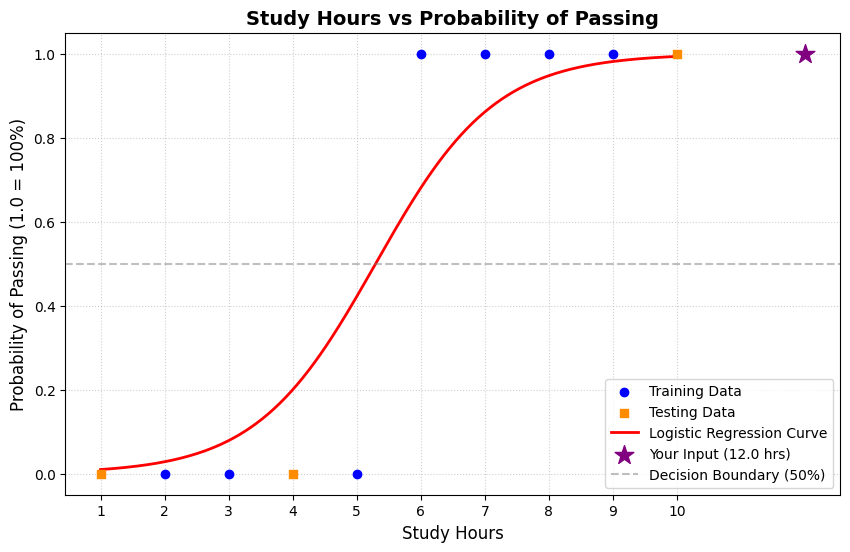

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dataset: Study hours and result
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Create and train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)

# Show accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))

# Take user input
hours = float(input("Enter study hours: "))

# Predict result
prediction = model.predict([[hours]])
probability = model.predict_proba([[hours]])

if prediction[0] == 1:
    print("Predicted Result: Pass")
else:
    print("Predicted Result: Fail")

print("Pass Probability:", round(probability[0][1] * 100, 2), "%")

# PLOT THE GRAPH
plt.figure(figsize=(10, 6))

# Plot the real data points (Train vs Test)
plt.scatter(X_train, y_train, color='blue', label='Training Data', zorder=5)
plt.scatter(X_test, y_test, color='darkorange', marker='s', label='Testing Data', zorder=5)

# Generate smooth lines for the Logistic Regression S-Curve (Sigmoid)
X_smooth = np.linspace(1, 10, 300).reshape(-1, 1)
y_prob_smooth = model.predict_proba(X_smooth)[:, 1] # Probability of class 1 (Pass)
plt.plot(X_smooth, y_prob_smooth, color='red', linewidth=2, label='Logistic Regression Curve')

# Plot the user's input dynamic prediction point
plt.scatter([[hours]], [probability[0][1]], color='purple', marker='*', s=200, label=f'Your Input ({hours} hrs)', zorder=6)

# Decision Boundary at 50% probability
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Decision Boundary (50%)')

# Formatting the Chart
plt.title('Study Hours vs Probability of Passing', fontsize=14, fontweight='bold')
plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Probability of Passing (1.0 = 100%)', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.xticks(np.arange(1, 11, 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

# Show graph
plt.show()